Завантажимо датасет

In [222]:
import pandas as pd
path = "./data/housing.csv"
df = pd.read_csv(path)
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Попередня обробка

In [223]:
from sklearn.preprocessing import LabelEncoder

# Приберемо рядки з порожніми даними
processed_df = df.dropna()

# Ми хочемо передбачити y - ціну будинку                                                                                  
y = processed_df["median_house_value"]
# За допомогою всіх інших параметрів                                                                                                                                                                                                          
X = processed_df.drop(columns=["median_house_value"])

In [224]:
print(processed_df.head())
le = LabelEncoder()

# Один з параметрів є текстом, а не числом - переведемо його в числовий вигляд
processed_df["ocean_proximity"] = le.fit_transform(processed_df["ocean_proximity"])

print(list(zip(le.classes_, range(len(le.classes_)))))   

print(processed_df.head())

X = processed_df.drop(columns=["median_house_value"])

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
[('<1H OCEAN', 0), ('INLAND', 1), ('ISLAND', 2), ('NEAR BAY', 3), ('NEAR OC

In [225]:
print(df[df['ocean_proximity'] == "NEAR BAY"].head(1))
print(df[df['ocean_proximity'] == "<1H OCEAN"].head(1))
print(df[df['ocean_proximity'] == "INLAND"].head(1))
print(df[df['ocean_proximity'] == "NEAR OCEAN"].head(1))
print(df[df['ocean_proximity'] == "ISLAND"].head(1))
df.head()

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
     longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
701    -121.97     37.64                32.0       1283.0           194.0   

     population  households  median_income  median_house_value ocean_proximity  
701       485.0       171.0         6.0574            431000.0       <1H OCEAN  
     longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
954    -121.92     37.64                46.0       1280.0           209.0   

     population  households  median_income  median_house_value ocean_proximity  
954       512.0       208.0         5.1406            315600.0          INLAND  
      longitude  latitude  housing_median_age  total_room

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Спробуємо використати моделі

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
naive_mod = KNeighborsRegressor()
# naive_mod.predict(X)

NotFittedError: This KNeighborsRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [234]:
from sklearn.linear_model import LinearRegression

mod = LinearRegression()
mod.fit(X, y)
print(y[:3])
mod.predict(X)[:3]

0    452600.0
1    358500.0
2    352100.0
Name: median_house_value, dtype: float64


array([411223.77904179, 415904.63320129, 380494.06641159])

In [235]:
from sklearn.neighbors import KNeighborsRegressor

mod = KNeighborsRegressor()
mod.fit(X, y)
print(y[:3])
mod.predict(X)[:3]

0    452600.0
1    358500.0
2    352100.0
Name: median_house_value, dtype: float64


array([314360. , 408180.4, 470420.8])

Подивимося на графіку, як справилася наша модель


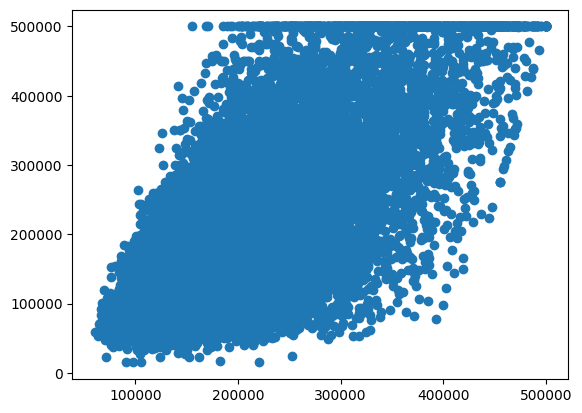

In [236]:
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pylab as plt

mod = KNeighborsRegressor().fit(X, y)
pred = mod.predict(X)
plt.scatter(pred, y)

Обєднаємо все в пайплайн

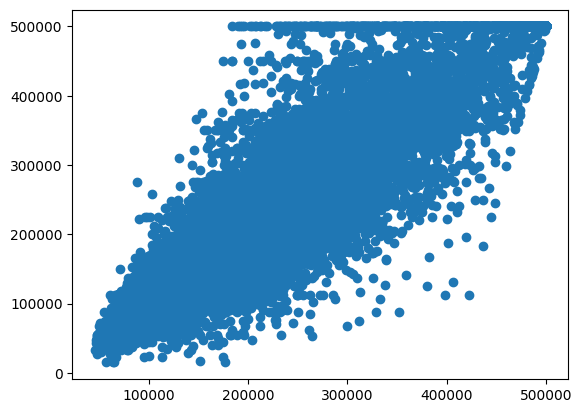

In [237]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pylab as plt

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsRegressor())
])
pred = pipe.fit(X, y).predict(X)
plt.scatter(pred, y)

Змінимо параметри моделі

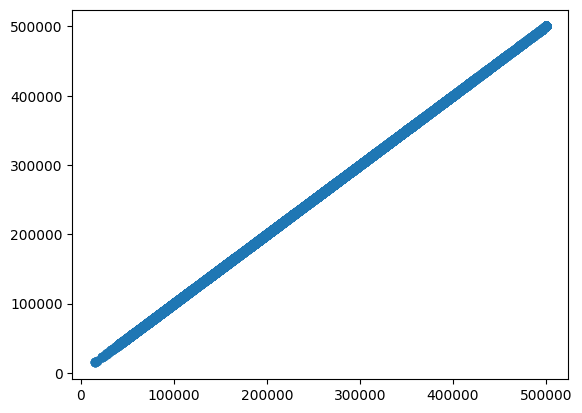

In [229]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pylab as plt


# При кількості сусідів = 1, для передбачення точки ми просто дивимося на її саму
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=1))
])
pred = pipe.fit(X, y).predict(X)
plt.scatter(pred, y)

Використаємо grid search для пошуку найоптимальніших параметрів моделі

In [238]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import pandas as pd

mod = GridSearchCV(estimator=pipe,
                 param_grid={
                   'model__n_neighbors': [1, 3, 5, 10, 20, 50],                                                                           
                   'model__p': [1, 2],  # Manhattan vs Euclidean
                 },
                 cv=5)
mod.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': [1, 3, ...], 'model__p': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : 

In [239]:
pd.DataFrame(mod.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,param_model__p,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.008439,0.002118,0.058211,0.008657,1,1,"{'model__n_neighbors': 1, 'model__p': 1}",0.242642,0.230579,0.443371,0.177196,0.487330,0.316224,0.124516,11
1,0.007062,0.000514,0.031956,0.004913,1,2,"{'model__n_neighbors': 1, 'model__p': 2}",0.245558,0.218760,0.447899,0.183587,0.484620,0.316085,0.124724,12
2,0.006925,0.000354,0.078074,0.011316,3,1,"{'model__n_neighbors': 3, 'model__p': 1}",0.467504,0.450826,0.603642,0.353429,0.617320,0.498544,0.099451,9
3,0.007559,0.001034,0.046472,0.004755,3,2,"{'model__n_neighbors': 3, 'model__p': 2}",0.488086,0.444071,0.596060,0.347656,0.612888,0.497752,0.098412,10
4,0.007402,0.000317,0.090260,0.010557,5,1,"{'model__n_neighbors': 5, 'model__p': 1}",0.504652,0.501636,0.626803,0.396950,0.631036,0.532215,0.087982,5
5,0.007063,0.000176,0.050599,0.007973,5,2,"{'model__n_neighbors': 5, 'model__p': 2}",0.528530,0.484581,0.617546,0.390845,0.632130,0.530726,0.088906,6
6,0.007136,0.000259,0.109965,0.012249,10,1,"{'model__n_neighbors': 10, 'model__p': 1}",0.517891,0.531291,0.641762,0.425831,0.638923,0.551140,0.081388,1
7,0.006810,0.000281,0.064484,0.010808,10,2,"{'model__n_neighbors': 10, 'model__p': 2}",0.537825,0.513721,0.632327,0.414192,0.639041,0.547421,0.083164,4
8,0.007164,0.000367,0.141197,0.016278,20,1,"{'model__n_neighbors': 20, 'model__p': 1}",0.508938,0.543595,0.635597,0.429202,0.633008,0.550068,0.078149,2
9,0.006983,0.000364,0.084693,0.011775,20,2,"{'model__n_neighbors': 20, 'model__p': 2}",0.528503,0.524794,0.633138,0.423808,0.630060,0.548061,0.077878,3


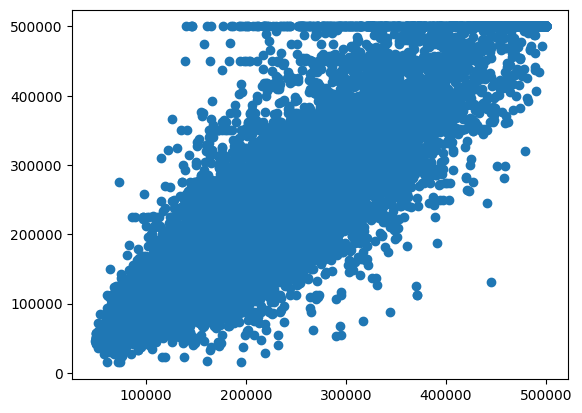

In [240]:
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=10, p=1))
])
pred = pipe.fit(X, y).predict(X)
plt.scatter(pred, y)